## 0. Title + abstract                              [narrative]
     What question, why it matters, one-line result

## 1. The well-mixed assumption & why it breaks     [narrative]
     Phase 1 assumes uniform T; cite Miller & Block on gradients

## 2. The physics                                   [narrative]
     heat equation, method of lines, BCs, source term
     the convection paradox + effective diffusivity (cite Bogard)

## 3. Parameters & provenance                       [analysis-light]
     show params table, each value → its paper

## 4. Stage 1 — verifying the boundary conditions   [analysis]
     run_diffusion_test, plot relaxation
     READ: relaxes to T_coolant, Neumann visible as vertical top

## 5. Stage 2 — the fermentation gradient           [analysis]
     run_with_fermentation, 3-panel figure
     READ: 2.3°C gradient, thermal lag

## 6. Grid independence test          ← #7          [analysis] ★
     run N=20, 40, 80, overlay peak gradients
     READ: converges → result is physics not artifact

## 7. Interpolation sensitivity       ← #8          [analysis] ★
     linear vs cubic dSdt_func, compare gradients
     READ: negligible difference → linear justified

## 8. Does the gradient MATTER?       ← #9          [analysis] ★★
     run Phase 1 biology at base T (12°C) vs top T (14.3°C)
     READ: different finish times → gradient changes the wine

## 9. Validation against literature                 [narrative]
     your ±3°C vs Bogard; μ_max vs Coleman

## 10. Known limitations                            [narrative]
     effective α, uniform source, Cp approximation

## 11. Conclusion + link to Phase 3                 [narrative]

In [1]:
#we want to check if the gradient depends on how many layers we use
#if the peak gradient converges as N increases ,the result is physical
import sys
sys.path.insert(0, "..")    # so imports work from notebooks/ directory

import numpy as np
import matplotlib.pyplot as plt
import copy

from src.process.spatial import (
    params,
    run_with_fermentation,
    heat_rhs_with_source,
    get_dSdt_profile,
)
from src.process.simulator import run_simulation, params as ferm_params

import copy

N= 10  →  peak gradient = 3.951 °C
N= 20  →  peak gradient = 3.953 °C
N= 40  →  peak gradient = 3.940 °C
N= 80  →  peak gradient = 3.940 °C


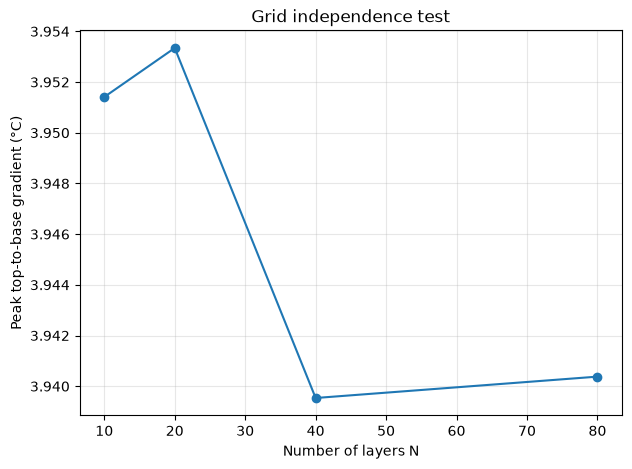

In [4]:


N_values=[10,20,40,80]

peak_gradients=[]

for N_test in N_values:
    p=copy.deepcopy(params)
    p["N"]=N_test
    p["dz"]=p["H"]/(p["N"]-1)


    sol, _ = run_with_fermentation(p, ferm_params) #sol has (N,n_timepoints)->n layers each sampled at n_timepoints times

    #peak gradient 
    top=sol.y[-1,:] #it takes the timepoints
    base=sol.y[0,:]
    grad=top-base
    
    peak_gradients.append(grad.max())

    print(f"N={N_test:3d}  →  peak gradient = {grad.max():.3f} °C")

# plot convergence
plt.figure(figsize=(7, 5))
plt.plot(N_values, peak_gradients, "o-")
plt.xlabel("Number of layers N")
plt.ylabel("Peak top-to-base gradient (°C)")
plt.title("Grid independence test")
plt.grid(True, alpha=0.3)
plt.show()







The peak fermentation-driven gradient converges rapidly:
- **N=40 vs N=80:** differ by little 
- **Interpretation:** grid-independent,not a discretization artifact


linear   →  peak gradient = 3.9395 °C
cubic    →  peak gradient = 3.9402 °C


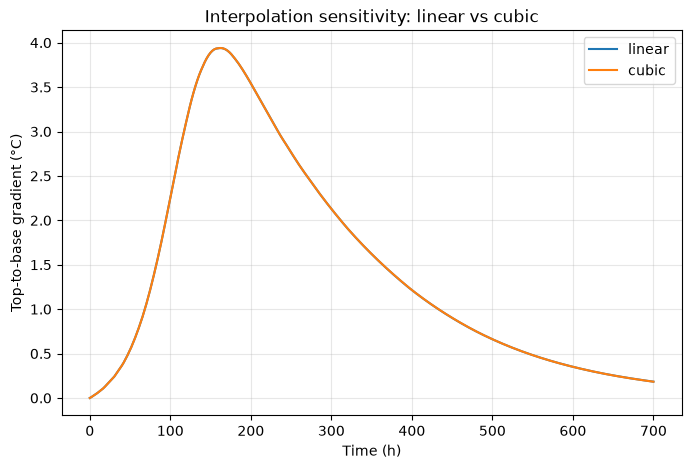

In [ ]:
#Ιnterpolation Sensitivity

#linear vs cubic interpolation of dS/dt change the result?
#linear is fast but introduces small kinks ,cubic is smoother

# Does linear vs cubic interpolation of dS/dt change the result?
# Linear is fast but introduces small kinks; cubic is smoother.
# If the gradient is the same either way, linear is justified.

from scipy.interpolate import interp1d

results = {}
for kind in ["linear", "cubic"]:
    p = copy.deepcopy(params)

    # rebuild the interpolator with this kind
    sol_ferm = run_simulation(ferm_params)
    t_end = sol_ferm.t[-1]
    t_eval = np.linspace(0, t_end, 300)
    dSdt_arr = get_dSdt_profile(t_eval, ferm_params)
    p["dSdt_func"] = interp1d(t_eval, dSdt_arr, kind=kind,
                              bounds_error=False, fill_value=0.0)

    # run with this interpolator 
    N = p["N"]
    T0 = np.full(N, p["T_initial"]); T0[0] = p["T_coolant"]
    from scipy.integrate import solve_ivp
    sol = solve_ivp(heat_rhs_with_source, (0, t_end), T0,
                    args=(p,), method="BDF",
                    t_eval=t_eval, dense_output=True)

    grad = (sol.y[-1, :] - sol.y[0, :])#sol.y is the results ,sol.t is the time (the independant variable)
    results[kind] = grad
    print(f"{kind:7s}  →  peak gradient = {grad.max():.4f} °C")

# overlay
plt.figure(figsize=(8, 5))
for kind, grad in results.items():
    plt.plot(t_eval, grad, label=kind)
plt.xlabel("Time (h)")
plt.ylabel("Top-to-base gradient (°C)")
plt.title("Interpolation sensitivity: linear vs cubic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()








they overlap so we are good->linear is justified (we use it because its faster)

We found that we have a gradient but does it change the fermentatiion? does it change the wine?
Does the yeast cell at the cold base ferments differently that one at the warm top?
At Coleman they found that fermentations at higher temperatures consistenly resulted in higher residual nitrogen levels at the end->this could be due to cell growth inhibition at higher temperatures 

#so we will run the fermentation twice one for T=12 °C  (cold base) and one for the warmer top T = 14.3°C

  Compare: how different are A and B?

#we expect  warmer = faster kinetics → the warm top ferments quicker, depletes sugar sooner, hits its endpoint earlier. 



In [4]:
import sys
sys.path.insert(0, "..")
import copy
import numpy as np
import matplotlib.pyplot as plt
from src.process.simulator import run_simulation, params as base_ferm_params

scenarios={
    "Cold base (12.0°C)": 12.0,
    "Warm top (14.3°C)":  14.3,
}

results={}

for label,T_val in scenarios.items():
    p=copy.deepcopy(base_ferm_params)
    p["T"]=T_val
    sol=run_simulation(p,t_end=700)
    results[label]=sol
    #report the endpoint
    print(f"{label}:  final sugar = {sol.y[2,-1]:6.1f} g/L   "
          f"final ethanol = {sol.y[4,-1]:5.1f} g/L   "
          f"ended at t = {sol.t[-1]:.0f} h")

Cold base (12.0°C):  final sugar =    8.2 g/L   final ethanol =  99.5 g/L   ended at t = 700 h
Warm top (14.3°C):  final sugar =    4.6 g/L   final ethanol = 101.3 g/L   ended at t = 700 h


THE GRADIENTS MATTERS : the warm top is drier and hotter -> it's a more aggressive fermentation. 
The cold base is sweeter and cooler —> it still has fuel left. Same tank, different wines at different heights.
 In real production, this is a mixing problem ->WE need to stir or circulate to keep fermentation uniform.


A **2.3°C spatial temperature gradient** (from Phase 2) translates to a 
**3.6 g/L difference in residual sugar** between the cold base and warm top.



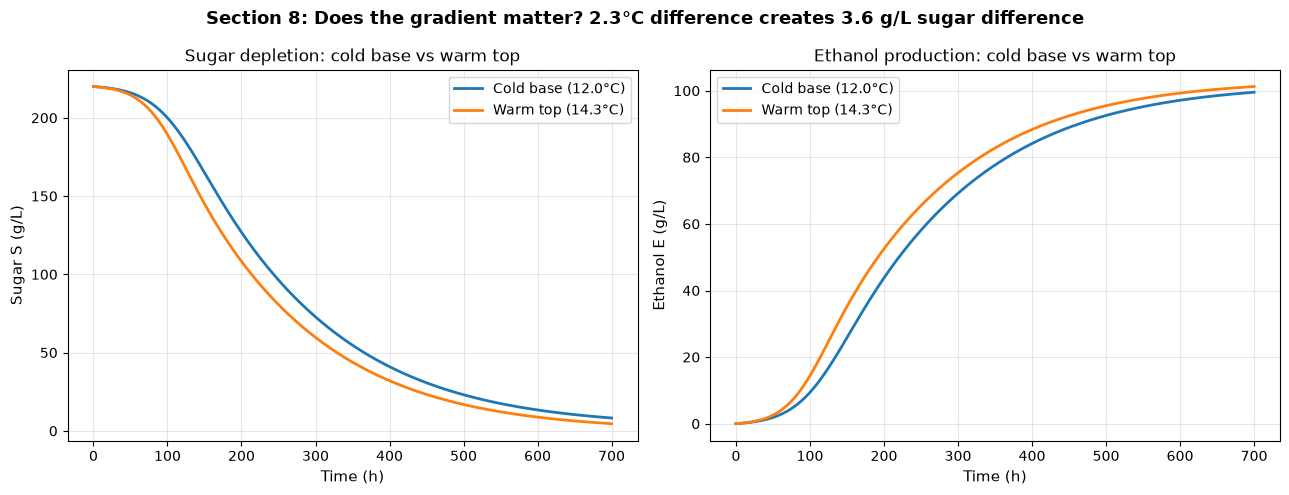

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, sol in results.items():
    axes[0].plot(sol.t, sol.y[2], label=label, linewidth=2)   # sugar (index 2)
    axes[1].plot(sol.t, sol.y[4], label=label, linewidth=2)   # ethanol (index 4)

axes[0].set_xlabel("Time (h)", fontsize=11)
axes[0].set_ylabel("Sugar S (g/L)", fontsize=11)
axes[0].set_title("Sugar depletion: cold base vs warm top", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Time (h)", fontsize=11)
axes[1].set_ylabel("Ethanol E (g/L)", fontsize=11)
axes[1].set_title("Ethanol production: cold base vs warm top", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

fig.suptitle("Section 8: Does the gradient matter? 2.3°C difference creates 3.6 g/L sugar difference", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/home/nasia/wine-innovation-engine/results/figures/phase2_gradient_matters.png", dpi=150)
plt.show()
